In [1]:
# ====================================================
# SECTION 01 - INSTALL DEPENDENCIES
# ====================================================

!pip install -q timm albumentations==1.4.4

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 150.4/150.4 kB 6.9 MB/s eta 0:00:00


In [4]:
# ====================================================
# SECTION 02 - IMPORT LIBRARIES
# ====================================================

import os
import gc
import cv2
import random
import warnings

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from tqdm import tqdm

import torch
import torch.nn as nn

from torch.utils.data import (
    Dataset,
    DataLoader
)

import timm

from sklearn.model_selection import StratifiedKFold

from sklearn.metrics import accuracy_score

import albumentations as A

from albumentations.pytorch import ToTensorV2

In [2]:
import os

for root, dirs, files in os.walk("/kaggle/input"):
    for f in files:
        if ".pth" in f:
            print(os.path.join(root, f))

/kaggle/input/models/devrojmala/krones-efficientnetv2s/pytorch/default/1/best_fold_1 (1).pth
/kaggle/input/models/devrojmala/krones-efficientnetv2s/pytorch/default/1/best_fold_0 (1).pth
/kaggle/input/models/devrojmala/krones-efficientnetv2s/pytorch/default/1/best_fold_2 (1).pth
/kaggle/input/models/devrojmala/krones-efficientnetv2s/pytorch/default/1/best_fold_3 (1).pth
/kaggle/input/models/devrojmala/krones-efficientnetv2s/pytorch/default/1/best_fold_4 (2).pth


In [3]:
WEIGHT_PATH = "/kaggle/input/models/devrojmala/krones-efficientnetv2s/pytorch/default/1/best_fold_0 (1).pth"

model = BottleModel().to(CFG.DEVICE)

state_dict = torch.load(
    WEIGHT_PATH,
    map_location=CFG.DEVICE
)

model.load_state_dict(state_dict)

print("Model Loaded Successfully")

NameError: name 'BottleModel' is not defined

In [8]:
# ====================================================
# SECTION 02 - IMPORT LIBRARIES
# ====================================================

import os
import gc
import cv2
import random
import warnings

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from tqdm import tqdm

import torch
import torch.nn as nn

from torch.utils.data import (
    Dataset,
    DataLoader
)

import timm

from sklearn.model_selection import StratifiedKFold

from sklearn.metrics import accuracy_score

import albumentations as A

from albumentations.pytorch import ToTensorV2

In [6]:
# ====================================================
# SECTION 03 - CHECK GPU
# ====================================================

print("CUDA Available :", torch.cuda.is_available())

if torch.cuda.is_available():

    print("GPU Name :", torch.cuda.get_device_name(0))

CUDA Available : True
GPU Name : Tesla T4


In [3]:
# ====================================================
# SECTION 04 - CHECK DATASET STRUCTURE
# ====================================================

for dirname, _, filenames in os.walk('/kaggle/input'):

    print(dirname)

/kaggle/input
/kaggle/input/competitions
/kaggle/input/competitions/1st-krones-vision-ai-challenge
/kaggle/input/competitions/1st-krones-vision-ai-challenge/test_images


In [7]:
# ====================================================
# SECTION 05 - SET DATASET PATHS
# ====================================================

BASE_PATH = "/kaggle/input/competitions/1st-krones-vision-ai-challenge"

TRAIN_DIR = f"{BASE_PATH}/train_images"

TEST_DIR = f"{BASE_PATH}/test_images"

TRAIN_CSV = f"{BASE_PATH}/train.csv"

SAMPLE_SUBMISSION = f"{BASE_PATH}/sample_submission.csv"

In [9]:
import torch
import torch.nn as nn
import timm

In [7]:
# ====================================================
# SECTION 06 - LOAD TRAIN CSV
# ====================================================

df = pd.read_csv(TRAIN_CSV)

print(df.head())

print("\nDataset Shape :", df.shape)

FileNotFoundError: [Errno 2] No such file or directory: '/kaggle/input/competitions/1st-krones-vision-ai-challenge/train.csv'

In [10]:
import os

for root, dirs, files in os.walk("/kaggle/working"):
    for f in files:
        if f.endswith(".pth"):
            print(os.path.join(root, f))

In [18]:
# ====================================================
# SECTION 07 - CHECK DATASET INFORMATION
# ====================================================

print("Columns :")
print(df.columns)

print("\nDataset Shape :")
print(df.shape)

print("\nLabel Distribution :")
print(df.target.value_counts())

Columns :
Index(['image_id', 'target'], dtype='object')

Dataset Shape :
(35342, 2)

Label Distribution :
target
1    20613
0    14729
Name: count, dtype: int64


KeyboardInterrupt: 

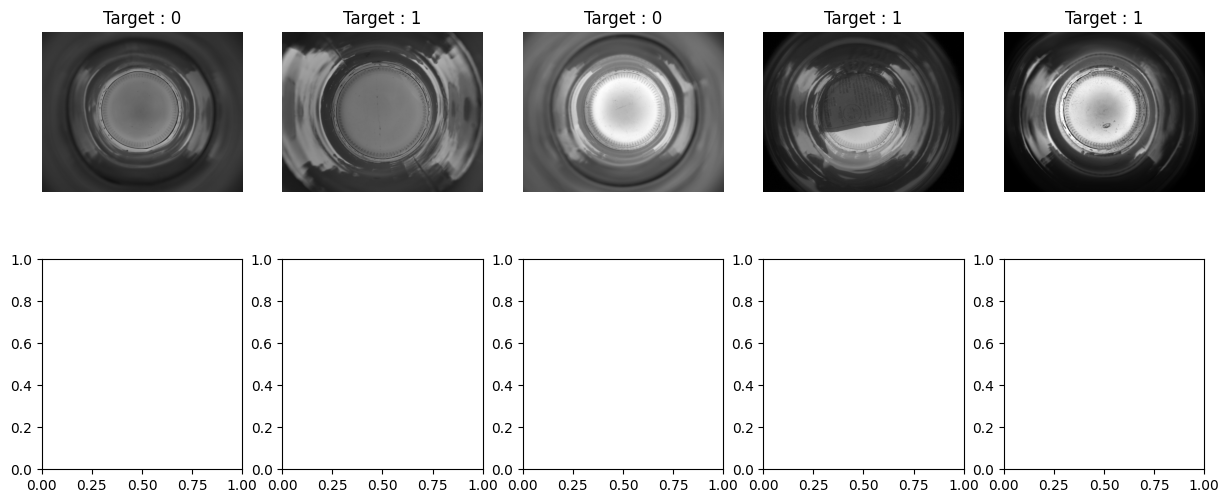

In [19]:
# ====================================================
# SECTION 08 - VISUALIZE SAMPLE IMAGES
# ====================================================

fig, axes = plt.subplots(2, 5, figsize=(15, 6))

for i, ax in enumerate(axes.flat):

    row = df.iloc[i]

    image_path = os.path.join(
        TRAIN_DIR,
        row.image_id
    )

    image = cv2.imread(image_path)

    image = cv2.cvtColor(
        image,
        cv2.COLOR_BGR2RGB
    )

    ax.imshow(image)

    ax.set_title(f"Target : {row.target}")

    ax.axis("off")

plt.tight_layout()

plt.show()

In [20]:
# ====================================================
# SECTION 09 - CHECK IMAGE SHAPE
# ====================================================

sample_path = os.path.join(
    TRAIN_DIR,
    df.iloc[0].image_id
)

image = cv2.imread(sample_path)

print("Image Shape :", image.shape)

Image Shape : (1024, 1280, 3)


In [22]:
# ====================================================
# SECTION 10 - SEED EVERYTHING
# ====================================================

def seed_everything(seed=42):

    random.seed(seed)

    np.random.seed(seed)

    torch.manual_seed(seed)

    torch.cuda.manual_seed(seed)

    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True

    torch.backends.cudnn.benchmark = False


seed_everything(42)

In [24]:
# ====================================================
# SECTION 11 - CONFIGURATION
# ====================================================

class CFG:

    IMAGE_SIZE = 384

    EPOCHS = 10

    BATCH_SIZE = 32

    LEARNING_RATE = 1e-4

    NUM_WORKERS = 8

    MODEL_NAME = "tf_efficientnetv2_s"

    DEVICE = "cuda"

    N_FOLDS = 5

    SEED = 42

In [25]:
# ====================================================
# SECTION 12 - CREATE STRATIFIED FOLDS
# ====================================================

kf = StratifiedKFold(
    n_splits=CFG.N_FOLDS,
    shuffle=True,
    random_state=CFG.SEED
)

df["fold"] = -1

for fold, (_, val_idx) in enumerate(
    kf.split(df, df.target)
):
    df.loc[val_idx, "fold"] = fold


# =====================================
# LOAD BOTTLE TYPES
# =====================================

bottle_df = pd.read_csv(
    "/kaggle/input/competitions/1st-krones-vision-ai-challenge/bottletypes.csv"
)

train_bottle_df = bottle_df[
    bottle_df["split"] == "train"
].copy()

df = df.merge(
    train_bottle_df[
        ["image_id", "bottle_type"]
    ],
    on="image_id",
    how="left"
)

bottle_mapping = {
    bottle: idx
    for idx, bottle in enumerate(
        sorted(df["bottle_type"].unique())
    )
}

df["bottle_type_id"] = (
    df["bottle_type"]
    .map(bottle_mapping)
    .astype(int)
)

print(df.head())

print("\nBottle Mapping:")
print(bottle_mapping)

                                            image_id  target  fold  \
0  ad0f5a12-93fe-4ebb-9aae-ef12ef5246f8_000000000...       0     1   
1  1d1ee6a4-5b1b-4280-a254-29b4cb5c1267_000000000...       1     1   
2  3710d5e0-832e-461b-8922-4b83308ae692_000000000...       0     3   
3  9a4a0c6c-4e26-4aba-8d59-f6dfe609fb21_000000000...       1     0   
4  799ec8dc-68a5-4690-90ba-7708d016e681_000000000...       1     4   

                   bottle_type  bottle_type_id  
0  0,33L Vichy brown crown cap               0  
1    0,5L Euro brown crown cap               1  
2  0,33L Vichy brown crown cap               0  
3     0,5L NRW brown crown cap               2  
4     0,5L NRW brown crown cap               2  

Bottle Mapping:
{'0,33L Vichy brown crown cap': 0, '0,5L Euro brown crown cap': 1, '0,5L NRW brown crown cap': 2}


In [26]:
# ====================================================
# SECTION 13 - CHECK FOLD DISTRIBUTION
# ====================================================

for fold in range(CFG.N_FOLDS):

    print(f"\nFold {fold}")

    print(

        df[df.fold == fold]
        .target
        .value_counts()

    )


Fold 0
target
1    4123
0    2946
Name: count, dtype: int64

Fold 1
target
1    4123
0    2946
Name: count, dtype: int64

Fold 2
target
1    4122
0    2946
Name: count, dtype: int64

Fold 3
target
1    4122
0    2946
Name: count, dtype: int64

Fold 4
target
1    4123
0    2945
Name: count, dtype: int64


In [27]:
# ====================================================
# SECTION 14 - TRAIN TRANSFORMS
# ====================================================

train_transforms = A.Compose([

    A.Resize(
        CFG.IMAGE_SIZE,
        CFG.IMAGE_SIZE
    ),

    A.RandomBrightnessContrast(
        brightness_limit=0.15,
        contrast_limit=0.15,
        p=0.4
    ),

    A.CLAHE(
        clip_limit=4.0,
        tile_grid_size=(8, 8),
        p=0.3
    ),

    A.RandomGamma(
        gamma_limit=(90, 110),
        p=0.2
    ),

    A.ShiftScaleRotate(
        shift_limit=0.02,
        scale_limit=0.02,
        rotate_limit=5,
        border_mode=cv2.BORDER_REFLECT_101,
        p=0.3
    ),

    A.Normalize(
        mean=(0.485, 0.456, 0.406),
        std=(0.229, 0.224, 0.225)
    ),

    ToTensorV2()

])

In [29]:
# ====================================================
# SECTION 15 - VALID AUGMENTATIONS
# ====================================================

valid_transforms = A.Compose([

    A.Resize(
        CFG.IMAGE_SIZE,
        CFG.IMAGE_SIZE
    ),

    A.Normalize(),

    ToTensorV2()

])

In [30]:
# ====================================================
# SECTION 16 - DATASET CLASS
# ====================================================

class BottleDataset(Dataset):

    def __init__(
        self,
        dataframe,
        transforms=None
    ):

        self.dataframe = dataframe.reset_index(drop=True)

        self.transforms = transforms

    def __len__(self):

        return len(self.dataframe)

    def __getitem__(self, idx):

        row = self.dataframe.iloc[idx]

        image_path = os.path.join(
            TRAIN_DIR,
            row.image_id
        )

        image = cv2.imread(image_path)

        image = cv2.cvtColor(
            image,
            cv2.COLOR_BGR2RGB
        )

        label = row.target

        bottle_type_id = row.bottle_type_id

        if self.transforms:

            image = self.transforms(
                image=image
            )["image"]

        return (
            image,
            torch.tensor(bottle_type_id).long(),
            torch.tensor(label).long()
        )

In [31]:
# ====================================================
# SECTION 17 - CREATE DATALOADERS
# ====================================================

fold = 0

train_df = df[df.fold != fold]

valid_df = df[df.fold == fold]

print("Train Size :", len(train_df))

print("Valid Size :", len(valid_df))


train_dataset = BottleDataset(
    train_df,
    transforms=train_transforms
)

valid_dataset = BottleDataset(
    valid_df,
    transforms=valid_transforms
)


train_loader = DataLoader(

    train_dataset,

    batch_size=CFG.BATCH_SIZE,

    shuffle=True,

    num_workers=CFG.NUM_WORKERS,

    pin_memory=True,

    persistent_workers=True

)

valid_loader = DataLoader(

    valid_dataset,

    batch_size=CFG.BATCH_SIZE,

    shuffle=False,

    num_workers=CFG.NUM_WORKERS,

    pin_memory=True,

    persistent_workers=True

)

Train Size : 28273
Valid Size : 7069


In [33]:
# ====================================================
# SECTION 18 - CHECK DATALOADER OUTPUT
# ====================================================

images, bottle_type_ids, labels = next(iter(train_loader))

print("Image Batch Shape :", images.shape)

print("Bottle Type Shape :", bottle_type_ids.shape)

print("Label Batch Shape :", labels.shape)

print("Bottle Types Sample :")

print(bottle_type_ids[:10])

Image Batch Shape : torch.Size([32, 3, 384, 384])
Bottle Type Shape : torch.Size([32])
Label Batch Shape : torch.Size([32])
Bottle Types Sample :
tensor([2, 2, 2, 2, 2, 1, 1, 2, 2, 2])


In [10]:
import torch
import torch.nn as nn
import timm

class CFG:
    MODEL_NAME = "tf_efficientnetv2_s"

In [11]:
# ====================================================
# SECTION 19 - BUILD MODEL
# ====================================================

class BottleModel(nn.Module):

    def __init__(self):

        super().__init__()

        self.backbone = timm.create_model(

            CFG.MODEL_NAME,

            pretrained=True,

            num_classes=0

        )

        backbone_features = self.backbone.num_features

        self.bottle_embedding = nn.Embedding(
            3,
            16
        )

        self.classifier = nn.Sequential(

            nn.Linear(
                backbone_features + 16,
                512
            ),

            nn.ReLU(),

            nn.Dropout(0.3),

            nn.Linear(
                512,
                2
            )
        )

    def forward(
        self,
        images,
        bottle_type_ids
    ):

        image_features = self.backbone(
            images
        )

        bottle_features = (
            self.bottle_embedding(
                bottle_type_ids
            )
        )

        features = torch.cat(

            [
                image_features,
                bottle_features
            ],

            dim=1
        )

        return self.classifier(
            features
        )

In [12]:
model = BottleModel()

print("BottleModel Loaded")

model.safetensors:   0%|          | 0.00/86.5M [00:00<?, ?B/s]

BottleModel Loaded


In [14]:
MODEL_PATHS = [
    "/kaggle/input/models/devrojmala/krones-efficientnetv2s/pytorch/default/1/best_fold_0 (1).pth",
    "/kaggle/input/models/devrojmala/krones-efficientnetv2s/pytorch/default/1/best_fold_1 (1).pth",
    "/kaggle/input/models/devrojmala/krones-efficientnetv2s/pytorch/default/1/best_fold_2 (1).pth",
    "/kaggle/input/models/devrojmala/krones-efficientnetv2s/pytorch/default/1/best_fold_3 (1).pth",
    "/kaggle/input/models/devrojmala/krones-efficientnetv2s/pytorch/default/1/best_fold_4 (2).pth",
]

for path in MODEL_PATHS:
    model = BottleModel()

    state_dict = torch.load(
        path,
        map_location="cpu"
    )

    model.load_state_dict(state_dict)

    print("Loaded:", path.split("/")[-1])

Loaded: best_fold_0 (1).pth


Loaded: best_fold_1 (1).pth
Loaded: best_fold_2 (1).pth
Loaded: best_fold_3 (1).pth
Loaded: best_fold_4 (2).pth


In [35]:
# ====================================================
# SECTION 20 - INITIALIZE MODEL
# ====================================================

model = BottleModel().to(CFG.DEVICE)

model.safetensors:   0%|          | 0.00/86.5M [00:00<?, ?B/s]

In [36]:
# ====================================================
# SECTION 21 - LOSS FUNCTION + OPTIMIZER
# ====================================================

criterion = nn.CrossEntropyLoss(
    label_smoothing=0.1
)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=CFG.LEARNING_RATE,
    weight_decay=1e-4
)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=CFG.EPOCHS,
    eta_min=1e-6
)

In [37]:
# ====================================================
# SECTION 22 - TRAIN FUNCTION
# ====================================================

scaler = torch.cuda.amp.GradScaler()

def train_one_epoch(
    model,
    loader,
    optimizer,
    criterion,
    scheduler
):

    model.train()

    running_loss = 0

    for images, bottle_type_ids, labels in tqdm(loader):

        images = images.to(CFG.DEVICE)

        bottle_type_ids = bottle_type_ids.to(CFG.DEVICE)

        labels = labels.to(CFG.DEVICE)

        optimizer.zero_grad()

        with torch.cuda.amp.autocast():

            outputs = model(
                images,
                bottle_type_ids
            )

            loss = criterion(
                outputs,
                labels
            )

        scaler.scale(loss).backward()

        scaler.step(optimizer)

        scaler.update()

        running_loss += loss.item()

    scheduler.step()

    epoch_loss = running_loss / len(loader)

    return epoch_loss

In [38]:
# ====================================================
# SECTION 23 - VALIDATION FUNCTION
# ====================================================

@torch.no_grad()

def valid_one_epoch(

    model,
    loader,
    criterion

):

    model.eval()

    running_loss = 0

    preds = []

    targets = []

    for images, bottle_type_ids, labels in tqdm(loader):

        images = images.to(CFG.DEVICE)

        bottle_type_ids = bottle_type_ids.to(CFG.DEVICE)

        labels = labels.to(CFG.DEVICE)

        outputs = model(

            images,
            bottle_type_ids

        )

        loss = criterion(
            outputs,
            labels
        )

        running_loss += loss.item()

        predictions = outputs.argmax(1)

        preds.extend(
            predictions.cpu().numpy()
        )

        targets.extend(
            labels.cpu().numpy()
        )

    epoch_loss = running_loss / len(loader)

    accuracy = accuracy_score(
        targets,
        preds
    )

    return epoch_loss, accuracy

In [40]:
# ====================================================
# SECTION 24 - SINGLE EPOCH TEST RUN
# ====================================================

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(

    optimizer,

    T_max=CFG.EPOCHS,

    eta_min=1e-6

)

train_loss = train_one_epoch(

    model,

    train_loader,

    optimizer,

    criterion,

    scheduler

)

valid_loss, valid_acc = valid_one_epoch(

    model,

    valid_loader,

    criterion

)

print(f"\nTrain Loss : {train_loss:.4f}")

print(f"Valid Loss : {valid_loss:.4f}")

print(f"Valid Accuracy : {valid_acc:.4f}")

100%|██████████| 221/221 [01:16<00:00,  2.90it/s]


Train Loss : 0.3330
Valid Loss : 0.2967
Valid Accuracy : 0.9410


In [ ]:
# ====================================================
# SECTION 25 - FULL TRAINING LOOP
# ====================================================

best_accuracy = 0

history = {

    "train_loss": [],

    "valid_loss": [],

    "valid_acc": []

}


for epoch in range(CFG.EPOCHS):

    print(f"\n{'='*25}")

    print(f"EPOCH {epoch+1}")

    print(f"{'='*25}")


    # =========================
    # TRAIN
    # =========================

    train_loss = train_one_epoch(

        model,
        train_loader,
        optimizer,
        criterion

    )


    # =========================
    # VALIDATE
    # =========================

    valid_loss, valid_acc = valid_one_epoch(

        model,
        valid_loader,
        criterion

    )


    # =========================
    # SAVE HISTORY
    # =========================

    history["train_loss"].append(train_loss)

    history["valid_loss"].append(valid_loss)

    history["valid_acc"].append(valid_acc)


    # =========================
    # PRINT METRICS
    # =========================

    print(f"\nTrain Loss : {train_loss:.4f}")

    print(f"Valid Loss : {valid_loss:.4f}")

    print(f"Valid Accuracy : {valid_acc:.4f}")


    # =========================
    # SAVE BEST MODEL
    # =========================

    if valid_acc > best_accuracy:

        best_accuracy = valid_acc

        torch.save(

            model.state_dict(),

            "best_model.pth"

        )

        print("\nBest Model Saved")


print(f"\nBest Validation Accuracy : {best_accuracy:.4f}")

In [ ]:
# ====================================================
# SECTION 25A - VALIDATION PROBABILITIES
# ====================================================

from sklearn.metrics import f1_score

model.eval()

valid_probs = []

valid_targets = []


with torch.no_grad():

    for images, labels in tqdm(valid_loader):

        images = images.to(CFG.DEVICE)

        outputs = model(images)

        probs = torch.softmax(
            outputs,
            dim=1
        )[:, 1]

        valid_probs.extend(
            probs.cpu().numpy()
        )

        valid_targets.extend(
            labels.numpy()
        )

In [ ]:
# ====================================================
# SECTION 25B - THRESHOLD SEARCH
# ====================================================

best_threshold = 0

best_f1 = 0


for threshold in np.arange(0.30, 0.81, 0.01):

    preds = (

        np.array(valid_probs) > threshold

    ).astype(int)

    score = f1_score(

        valid_targets,

        preds

    )

    if score > best_f1:

        best_f1 = score

        best_threshold = threshold


print(f"Best Threshold : {best_threshold:.2f}")

print(f"Best F1 Score : {best_f1:.4f}")

In [61]:
# ====================================================
# SECTION 26 - LOAD SAMPLE SUBMISSION
# ====================================================

submission_df = pd.read_csv(SAMPLE_SUBMISSION)

print(submission_df.head())

print("\nSubmission Shape :", submission_df.shape)

                                            image_id  target
0  64e50373-1f39-40e7-b821-655246c7a30e_000000000...       0
1  43b0c8b4-75b6-40b2-b867-ea2779f6ecec_000000000...       0
2  50269c78-2962-42a0-ac21-e83155eaeeb3_000000000...       1
3  a13c8c3d-ace7-4b58-8a25-697e6d3d4bc5_000000000...       0
4  0f06081b-03f9-4179-ab26-cd402f40e43c_000000000...       0

Submission Shape : (4418, 2)


In [62]:
# ====================================================
# SECTION 27 - TEST DATASET CLASS
# ====================================================

class TestDataset(Dataset):

    def __init__(

        self,
        dataframe,
        transforms=None

    ):

        self.dataframe = dataframe.reset_index(drop=True)

        self.transforms = transforms


    def __len__(self):

        return len(self.dataframe)


    def __getitem__(self, idx):

        row = self.dataframe.iloc[idx]

        image_id = row.image_id

        bottle_type_id = row.bottle_type_id

        image_path = os.path.join(
            TEST_DIR,
            image_id
        )

        image = cv2.imread(image_path)

        image = cv2.cvtColor(
            image,
            cv2.COLOR_BGR2RGB
        )

        if self.transforms:

            image = self.transforms(
                image=image
            )["image"]

        return (

            image,

            torch.tensor(
                bottle_type_id
            ).long()

        )

In [63]:
# ====================================================
# SECTION 28 - CREATE TEST DATASET
# ====================================================

bottle_df = pd.read_csv(
    "/kaggle/input/competitions/1st-krones-vision-ai-challenge/bottletypes.csv"
)

test_bottle_df = bottle_df[
    bottle_df["split"] == "test"
].copy()

test_bottle_df["bottle_type_id"] = (
    test_bottle_df["bottle_type"]
    .map(bottle_mapping)
    .astype(int)
)

submission_df = submission_df.merge(
    test_bottle_df[
        ["image_id", "bottle_type_id"]
    ],
    on="image_id",
    how="left"
)

test_dataset = TestDataset(

    submission_df,

    transforms=valid_transforms

)

test_loader = DataLoader(

    test_dataset,

    batch_size=CFG.BATCH_SIZE,

    shuffle=False,

    num_workers=CFG.NUM_WORKERS,

    pin_memory=True

)

print(
    len(test_dataset)
)

4418


In [ ]:
# ====================================================
# SECTION 29 - LOAD BEST MODEL
# ====================================================

model = BottleModel().to(CFG.DEVICE)

model.load_state_dict(

    torch.load("best_model.pth")

)

model.eval()

print("Best model loaded successfully")

In [ ]:
# ====================================================
# SECTION 30 - TEST INFERENCE
# ====================================================

predictions = []

model.eval()

with torch.no_grad():

    for images, bottle_type_ids in test_loader:

        images = images.to(CFG.DEVICE)

        bottle_type_ids = bottle_type_ids.to(CFG.DEVICE)

        outputs = model(
            images,
            bottle_type_ids
        )

        probs = torch.softmax(
            outputs,
            dim=1
        )[:, 1]

        preds = (
            probs > best_threshold
        ).long()

        predictions.extend(
            preds.cpu().numpy()
        )

In [48]:
print(submission_df.shape)

(4418, 3)


In [ ]:
# ====================================================
# SECTION 31 - CREATE SUBMISSION
# ====================================================

submission_df["target"] = predictions

submission_df.to_csv(

    "submission.csv",

    index=False

)

print(submission_df.head())

print("\nSubmission file saved")

In [ ]:
# ====================================================
# SECTION 32 - CHECK SUBMISSION FILE
# ====================================================

os.listdir()

In [41]:
print(df["bottle_type_id"].isna().sum())

0


In [43]:
# ====================================================
# SECTION 33 - FULL FOLD TRAINING PIPELINE
# ====================================================

all_fold_scores = []

for fold in range(CFG.N_FOLDS):

    print(f"\n{'='*40}")
    print(f"TRAINING FOLD {fold}")
    print(f"{'='*40}")

    # ==========================================
    # SPLIT DATA
    # ==========================================

    train_df = df[df.fold != fold]
    valid_df = df[df.fold == fold]

    # ==========================================
    # DATASETS
    # ==========================================

    train_dataset = BottleDataset(
        train_df,
        transforms=train_transforms
    )

    valid_dataset = BottleDataset(
        valid_df,
        transforms=valid_transforms
    )

    # ==========================================
    # DATALOADERS
    # ==========================================

    train_loader = DataLoader(
        train_dataset,
        batch_size=CFG.BATCH_SIZE,
        shuffle=True,
        num_workers=CFG.NUM_WORKERS,
        pin_memory=True,
        persistent_workers=True
    )

    valid_loader = DataLoader(
        valid_dataset,
        batch_size=CFG.BATCH_SIZE,
        shuffle=False,
        num_workers=CFG.NUM_WORKERS,
        pin_memory=True,
        persistent_workers=True
    )

    # ==========================================
    # MODEL
    # ==========================================

    model = BottleModel().to(CFG.DEVICE)

    # ==========================================
    # LOSS + OPTIMIZER
    # ==========================================

    criterion = nn.CrossEntropyLoss(
        label_smoothing=0.1
    )

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=CFG.LEARNING_RATE
    )

    # ==========================================
    # SCHEDULER
    # ==========================================

    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer,
        T_max=CFG.EPOCHS,
        eta_min=1e-6
    )

    # ==========================================
    # TRACK BEST
    # ==========================================

    best_accuracy = 0

    # ==========================================
    # EPOCH LOOP
    # ==========================================

    for epoch in range(CFG.EPOCHS):

        print(f"\nFOLD {fold} - EPOCH {epoch+1}")

        train_loss = train_one_epoch(
            model,
            train_loader,
            optimizer,
            criterion,
            scheduler
        )

        valid_loss, valid_acc = valid_one_epoch(
            model,
            valid_loader,
            criterion
        )

        print(f"\nTrain Loss : {train_loss:.4f}")
        print(f"Valid Loss : {valid_loss:.4f}")
        print(f"Valid Accuracy : {valid_acc:.4f}")

        if valid_acc > best_accuracy:

            best_accuracy = valid_acc

            torch.save(
                model.state_dict(),
                f"best_fold_{fold}.pth"
            )

            print("\nBest Fold Model Saved")

    all_fold_scores.append(best_accuracy)

    print(f"\nBest Fold {fold} Accuracy : {best_accuracy:.4f}")

print("\n==============================")
print("ALL FOLD SCORES")
print(all_fold_scores)

print(
    f"\nMean Accuracy : {np.mean(all_fold_scores):.4f}"
)


TRAINING FOLD 0

FOLD 0 - EPOCH 1


100%|██████████| 221/221 [01:14<00:00,  2.95it/s]



Train Loss : 0.3315
Valid Loss : 0.2875
Valid Accuracy : 0.9445

Best Fold Model Saved

FOLD 0 - EPOCH 2


100%|██████████| 221/221 [01:14<00:00,  2.95it/s]



Train Loss : 0.2845
Valid Loss : 0.2909
Valid Accuracy : 0.9455

Best Fold Model Saved

FOLD 0 - EPOCH 3


...


Train Loss : 0.2123
Valid Loss : 0.3051
Valid Accuracy : 0.9492

Best Fold Model Saved

FOLD 4 - EPOCH 9


100%|██████████| 221/221 [01:14<00:00,  2.97it/s]



Train Loss : 0.2078
Valid Loss : 0.3042
Valid Accuracy : 0.9503

Best Fold Model Saved

FOLD 4 - EPOCH 10


100%|██████████| 221/221 [01:14<00:00,  2.97it/s]


Train Loss : 0.2060
Valid Loss : 0.3038
Valid Accuracy : 0.9501

Best Fold 4 Accuracy : 0.9503

ALL FOLD SCORES
[0.9500636582260574, 0.956712406280945, 0.9516129032258065, 0.9521788341822298, 0.950339558573854]

Mean Accuracy : 0.9522


In [59]:
next(iter(test_loader))

[tensor([[[[-2.0323, -2.0837, -2.0323,  ..., -2.0665, -2.0665, -2.0837],
           [-2.1179, -1.9980, -1.9638,  ..., -2.0323, -2.0665, -2.0152],
           [-2.0494, -1.9638, -1.9124,  ..., -2.0837, -2.0665, -2.1179],
           ...,
           [-2.0152, -1.8439, -1.8953,  ..., -2.0152, -2.0152, -1.9295],
           [-1.9295, -1.9295, -1.9638,  ..., -1.8439, -1.9809, -1.9295],
           [-1.9980, -2.0152, -1.9124,  ..., -1.8953, -1.8610, -1.8953]],
 
          [[-1.9482, -2.0007, -1.9482,  ..., -1.9832, -1.9832, -2.0007],
           [-2.0357, -1.9132, -1.8782,  ..., -1.9482, -1.9832, -1.9307],
           [-1.9657, -1.8782, -1.8256,  ..., -2.0007, -1.9832, -2.0357],
           ...,
           [-1.9307, -1.7556, -1.8081,  ..., -1.9307, -1.9307, -1.8431],
           [-1.8431, -1.8431, -1.8782,  ..., -1.7556, -1.8957, -1.8431],
           [-1.9132, -1.9307, -1.8256,  ..., -1.8081, -1.7731, -1.8081]],
 
          [[-1.7173, -1.7696, -1.7173,  ..., -1.7522, -1.7522, -1.7696],
           [-

In [60]:
import os

for i in range(5):
    print(
        f"best_fold_{i}.pth",
        os.path.exists(f"best_fold_{i}.pth")
    )

best_fold_0.pth True
best_fold_1.pth True
best_fold_2.pth True
best_fold_3.pth True
best_fold_4.pth True


In [64]:
# ====================================================
# SECTION 34 - FULL 5 FOLD TTA ENSEMBLE
# ====================================================

test_probs = np.zeros(len(submission_df))

# --------------------------------------------
# WEIGHTED ENSEMBLE
# --------------------------------------------

fold_weights = [

    0.19,   # Fold 0
    0.21,   # Fold 1
    0.20,   # Fold 2
    0.21,   # Fold 3
    0.19    # Fold 4

]

# --------------------------------------------
# START INFERENCE
# --------------------------------------------

for fold in range(CFG.N_FOLDS):

    print(f"\nRunning Fold {fold}")

    model = BottleModel().to(CFG.DEVICE)

    model.load_state_dict(

        torch.load(

            f"best_fold_{fold}.pth",

            map_location=CFG.DEVICE

        )

    )

    model.eval()

    preds = []

    with torch.no_grad():

        for images, bottle_type_ids in tqdm(test_loader):

            images = images.to(CFG.DEVICE)

            bottle_type_ids = bottle_type_ids.to(CFG.DEVICE)

            # ====================================
            # ORIGINAL IMAGE
            # ====================================

            outputs1 = model(

                images,

                bottle_type_ids

            )

            probs1 = torch.softmax(

                outputs1,

                dim=1

            )[:, 1]

            # ====================================
            # HORIZONTAL FLIP TTA
            # ====================================

            flipped_images = torch.flip(

                images,

                dims=[3]

            )

            outputs2 = model(

                flipped_images,

                bottle_type_ids

            )

            probs2 = torch.softmax(

                outputs2,

                dim=1

            )[:, 1]

            # ====================================
            # TTA AVERAGE
            # ====================================

            probs = (

                probs1 + probs2

            ) / 2

            preds.extend(

                probs.cpu().numpy()

            )

    test_probs += (

        np.array(preds)

        * fold_weights[fold]

    )

# --------------------------------------------
# NORMALIZE
# --------------------------------------------

test_probs = test_probs / sum(fold_weights)

print("\nFull 5-Fold TTA Ensemble Completed")


Running Fold 0


100%|██████████| 139/139 [01:33<00:00,  1.48it/s]



Running Fold 1


100%|██████████| 139/139 [01:33<00:00,  1.49it/s]



Running Fold 2


...


Running Fold 3


100%|██████████| 139/139 [01:32<00:00,  1.49it/s]



Running Fold 4


100%|██████████| 139/139 [01:32<00:00,  1.50it/s]


Full 5-Fold TTA Ensemble Completed


In [65]:
# ====================================================
# SECTION 35 - CREATE FINAL SUBMISSION
# ====================================================

submission_df["target"] = (

    test_probs > 0.50

).astype(int)

submission_df.head()

,image_id,target,bottle_type_id
0,64e50373-1f39-40e7-b821-655246c7a30e_000000000...,1,2
1,43b0c8b4-75b6-40b2-b867-ea2779f6ecec_000000000...,1,2
2,50269c78-2962-42a0-ac21-e83155eaeeb3_000000000...,0,2
3,a13c8c3d-ace7-4b58-8a25-697e6d3d4bc5_000000000...,0,0
4,0f06081b-03f9-4179-ab26-cd402f40e43c_000000000...,1,2


In [66]:
# ====================================================
# SECTION 36 - SAVE SUBMISSION
# ====================================================

submission_df[

    ["image_id", "target"]

].to_csv(

    "submission_final.csv",

    index=False

)

print(submission_df.head())

print("\nSubmission Saved Successfully")

                                            image_id  target  bottle_type_id
0  64e50373-1f39-40e7-b821-655246c7a30e_000000000...       1               2
1  43b0c8b4-75b6-40b2-b867-ea2779f6ecec_000000000...       1               2
2  50269c78-2962-42a0-ac21-e83155eaeeb3_000000000...       0               2
3  a13c8c3d-ace7-4b58-8a25-697e6d3d4bc5_000000000...       0               0
4  0f06081b-03f9-4179-ab26-cd402f40e43c_000000000...       1               2

Submission Saved Successfully


In [ ]:
!cp "/kaggle/input/datasets/devrojmala/krones-fold-models/best_fold_0 (1).pth" best_fold_0.pth

!cp "/kaggle/input/datasets/devrojmala/krones-fold-models/best_fold_1 (1).pth" best_fold_1.pth

!cp "/kaggle/input/datasets/devrojmala/krones-fold-models/best_fold_2 (1).pth" best_fold_2.pth

!cp "/kaggle/input/datasets/devrojmala/krones-fold-models/best_fold_3 (1).pth" best_fold_3.pth

In [ ]:
!ls /kaggle/working/*.pth

In [ ]:
!zip -r fold_models.zip /kaggle/working/*.pth